In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA = Path("../../data")

LABELS = ["ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA", "Lateral OA",
          "PF OA", "Effusion", "Synovitis", "Baker's", "Contusion", "Fracture"]

# X / Y / Z are the three radiological planes: a stack steps along the axis its
# images are perpendicular to - sagittal along x, coronal along y, axial along z.
AXIS_PLANE = {"X": "Sagittal", "Y": "Coronal", "Z": "Axial"}

studies = pd.read_csv(DATA / "train.csv")          # one row per study: Report + 12 labels
series = pd.read_csv(DATA / "train_series.csv")    # one row per series: plane + flags

# extract fully reported and labeled (one of the 58 available) study that comes from kaggle

In [2]:
# 58 of the 4,407 studies carry all 12 labels; the rest are report-only. Take the
# first by UID, so re-running always describes the same knee.
gold = studies[studies[LABELS].notna().all(axis=1)]
study = gold.sort_values("StudyInstanceUID").iloc[0]
print("fully labeled studies:", len(gold), "\n")

fully labeled studies: 58 



# from that serie : return the 3 sets of images (x / y and z)

In [3]:
# One series per plane. A study holds 1-7 series per plane, so it needs a rule:
# fluid-sensitive (PD/T2 fat-sat) wins, since most of the 12 findings are fluid.
mine = series[series.StudyInstanceUID == study.StudyInstanceUID]

sets = {}
for axis, plane in AXIS_PLANE.items():
    row = (mine[mine.Anatomical_Plane == plane]
           .sort_values(["Fluid_Sensitive", "SeriesInstanceUID"], ascending=[False, True])
           .iloc[0])
    sets[axis] = np.load(DATA / "volumes" / f"{row.SeriesInstanceUID}.npz")["data"]
    print("{}  {:<9} {} images of {}x{}  {}".format(
        axis, plane, *sets[axis].shape, sets[axis].dtype))

X  Sagittal  24 images of 224x224  uint8
Y  Coronal   24 images of 224x224  uint8
Z  Axial     24 images of 224x224  uint8


# Print Sagittal

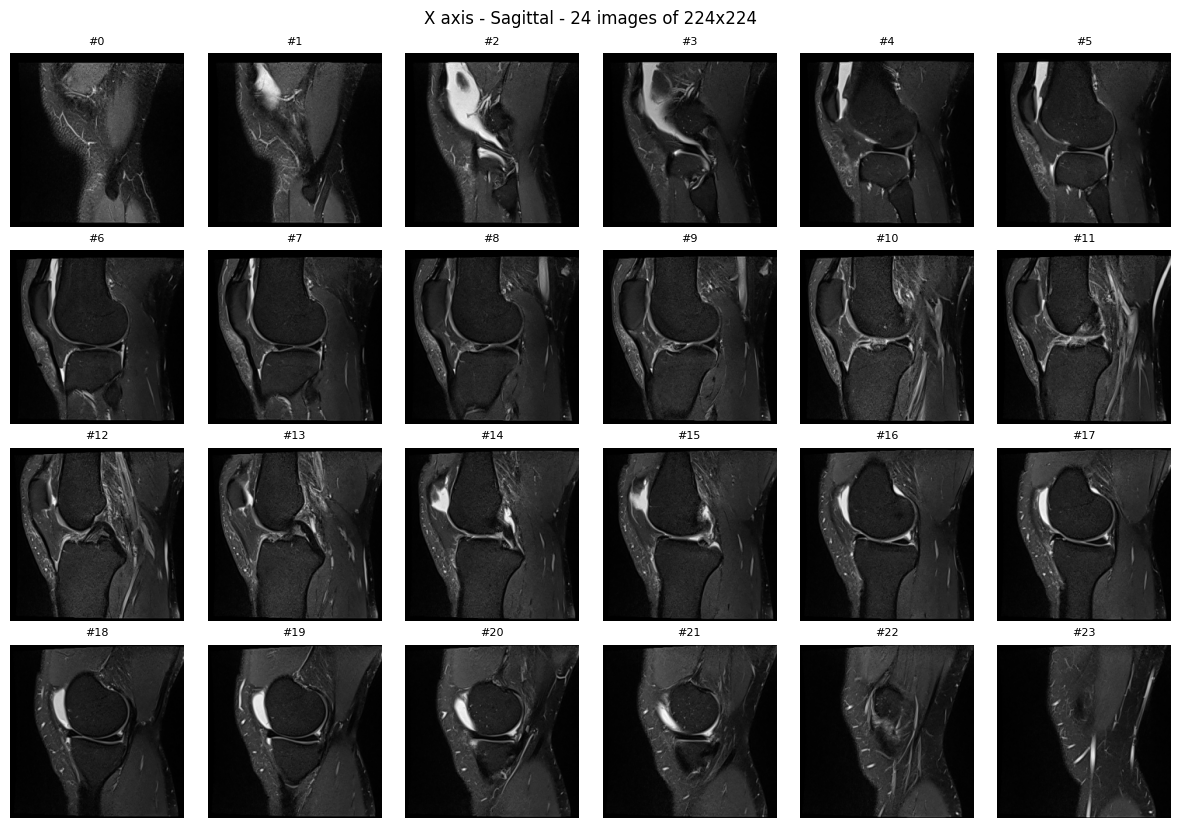

In [4]:
# Print only X: every image in the sagittal set, in stack order.
import matplotlib.pyplot as plt

x = sets["X"]
cols = 6
rows = -(-len(x) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.1 * rows))
for i, ax in enumerate(axes.ravel()):
    ax.axis("off")
    if i < len(x):
        ax.imshow(x[i], cmap="gray")
        ax.set_title(f"#{i}", fontsize=8)
fig.suptitle("X axis - Sagittal - {} images of {}x{}".format(*x.shape))
plt.tight_layout()
plt.show()

# Turn one Axis into a Tensor

We want one function: a StudyInstanceUID goes in, and out comes

- `x` : the X images as `(24, 224, 224, 1)` decimals between 0 and 1
- `y` : the 12 findings as a vector

1 channel, because the images are monochrome - three identical copies would just cost
3x the memory. A pretrained backbone that wants 3 channels gets the repeat inside the
model, where it is nearly free, not baked into every file we load.

Then a generator on top, so a batch can be pulled without holding 4,407 studies in memory.

In [5]:
# Soft labels, because only 58 studies carry real ones - these cover all 4,407.
# They repeat on every series row of a study, so one row per study is enough.
index = pd.read_csv(DATA / "meta" / "train_index.csv")
SOFT = ["soft_" + label for label in LABELS]
by_study = index.drop_duplicates("StudyInstanceUID").set_index("StudyInstanceUID")

def study_to_tensor(uid, axis="X"):
    """StudyInstanceUID -> ((24, 224, 224, 1) float32 in [0, 1], 12 labels)."""
    rows = series[series.StudyInstanceUID == uid]
    row = (rows[rows.Anatomical_Plane == AXIS_PLANE[axis]]
           .sort_values(["Fluid_Sensitive", "SeriesInstanceUID"], ascending=[False, True])
           .iloc[0])
    vol = np.load(DATA / "volumes" / f"{row.SeriesInstanceUID}.npz")["data"]   # (24,224,224) uint8
    x = vol[..., None].astype(np.float32) / 255.0                              # -> (24,224,224,1)
    y = by_study.loc[uid, SOFT].to_numpy(dtype=np.float32)
    return x, y

x, y = study_to_tensor(study.StudyInstanceUID)
print("x", x.shape, x.dtype, "range [{:.2f}, {:.2f}]  {:.1f} MB".format(x.min(), x.max(), x.nbytes / 1e6))
print("y", y.shape, dict(zip(LABELS, y.round(2))))

x (24, 224, 224, 1) float32 range [0.00, 0.98]  4.8 MB
y (12,) {'ACL': np.float32(0.02), 'MCL': np.float32(0.02), 'Medial Meniscus': np.float32(0.02), 'Lateral Meniscus': np.float32(0.46), 'Medial OA': np.float32(0.02), 'Lateral OA': np.float32(0.02), 'PF OA': np.float32(0.98), 'Effusion': np.float32(0.91), 'Synovitis': np.float32(0.33), "Baker's": np.float32(0.02), 'Contusion': np.float32(0.02), 'Fracture': np.float32(0.02)}


In [6]:
# One study in memory at a time - 4.8 MB each, so all 4,407 would not fit.
# For an ImageNet-pretrained backbone, repeat to 3 channels in the model:
#     keras.layers.Concatenate()([inp, inp, inp])
import tensorflow as tf

def make_dataset(uids, batch_size=4, axis="X"):
    signature = (tf.TensorSpec((24, 224, 224, 1), tf.float32), tf.TensorSpec((12,), tf.float32))
    return (tf.data.Dataset
            .from_generator(lambda: (study_to_tensor(u, axis) for u in uids),
                            output_signature=signature)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

train_uids = by_study.index[by_study.fold != 0]          # folds 1-4 train, fold 0 validates
xb, yb = next(iter(make_dataset(train_uids[:8], batch_size=4)))
print("train studies:", len(train_uids))
print("batch x", xb.shape, "  batch y", yb.shape)

train studies: 3525
batch x (4, 24, 224, 224, 1)   batch y (4, 12)


In [ ]:
x.shape

(24, 224, 224, 1)

In [19]:
# as (24,224,224,1) is Tensor

# Any slice count -> one tensor shape

The mirror is uniform `(24, 224, 224)`, but the raw series it was built from are not:
locally they run **16 to 160 slices**. Two places still meet that spread - the submit
kernel, which decodes the hidden test straight from DICOM, and the `hires` profile,
which wants 32. Both need one rule for turning any `n` into `K`.

The variable axis is **0**. Axes 1 and 2 are the two 224s and never move.

In [ ]:
# tf.image.resize reads (H, W, C). Feed it (n, 224, 224) and depth becomes the height:
# resizing height n -> K resamples the stack and leaves each image untouched. Staying in
# the graph matters - this runs inside tf.data, with no scipy and no numpy round-trip.
import tensorflow as tf

K = 24

def to_depth(vol, k=K, method="nearest"):
    """(n, 224, 224) for any n -> (k, 224, 224). Depth only; the images are not resized."""
    return tf.image.resize(vol, [k, vol.shape[1]], method=method)

for n in (16, 22, 24, 40, 160, 1):
    out = to_depth(tf.zeros((n, 224, 224), tf.uint8))
    print(f"n={n:>3} -> {tuple(out.shape)}  {out.dtype.name}")

In [ ]:
# nearest, not bilinear. M4 encodes slices with TimeDistributed, so it never sees depth
# continuity: an interpolated in-between slice teaches it nothing and blurs small findings.
sub = sets["X"][:17]                      # a 17-slice series, cut from the mirror
verbatim = lambda out: sum(any((out[i] == s).all() for s in sub) for i in range(K))

for method in ("nearest", "bilinear"):
    out = to_depth(tf.constant(sub, tf.float32), method=method).numpy()
    print(f"{method:<9} {verbatim(out):>2}/{K} of the output slices exist in the source")

In [ ]:
# What should K be? Nothing in the CSVs carries a slice count, so count the DICOMs.
import glob

n_raw = np.array(sorted(len(glob.glob(f"{d}/*.dcm"))
                        for d in glob.glob(str(DATA / "img_sequences" / "*" / "*"))))
print(f"{len(n_raw)} raw series held locally   median {np.median(n_raw):.0f}   "
      f"range {n_raw.min()}-{n_raw.max()}\n")

print(f"{'K':>4} {'downsampled':>12} {'upsampled':>10} {'median kept':>12} {'encoder':>8}")
for k in (16, 20, 24, 28, 32, 40):
    print(f"{k:>4} {(n_raw > k).mean():>11.0%} {(n_raw < k).mean():>9.0%} "
          f"{np.median(np.minimum(k / n_raw, 1.0)):>11.0%} {k / 24:>7.2f}x")

**Read this as a shape, not a verdict.** It is 58 series out of 24,371 - the only raw
DICOM we hold locally - so the median can move. Rerun the cell above on Kaggle, where the
full corpus is mounted, before changing `K`.

What the shape says so far: the median series is ~31 slices, so `K=24` discards slices on
about 70% of them and keeps ~78% of what was acquired. `K=32` sits on the median and costs
**1.33x** encoder time on every study - more than the 5th slot §2 already rejected at
+25%. So 24 stays, and the loss is smaller than it looks: the outer slices of a knee
stack are mostly air.

Carry `n_raw` into the manifest either way. A 160-slice series cut to 24 has dropped 85%
of its acquisition, and nothing downstream can tell it apart from a native 24-slice one.